**Dataset:** Medical Segmentation Decathlon — Task 07  
**Purpose:** Exploratory Data Analysis of CT volumes  
and segmentation masks before model development

---

### Contents
- Section A — Setup & Overview
- Section B — Dataset Structure
- Section C — Data Integrity Checks
- Section D — Class Labels and Balance
- Section E — Image Properties
- Section F — Distribution of Image Sizes
- Section G — Pixel Intensity Histograms
- Section H — Mean and Standard Deviation Analysis
- Section I — Slice-Level Risk Score Label Definition
- Section J — Visual Inspection of Sample Images
- Section K — Preprocessing Plan

## Section A — Setup & Overview

### A1. Imports & Setup

In [1]:
# ── Imports ───────────────────────────────────────────
import os
import json
import random
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter   # tally orientation codes across patients (integrity check)
from matplotlib.patches import Patch

# ── Display settings ──────────────────────────────────
%matplotlib inline
plt.rcParams['figure.dpi']      = 120
plt.rcParams['font.size']       = 11
plt.rcParams['axes.titlesize']  = 12
plt.rcParams['axes.labelsize']  = 11

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


### A2. Helper Functions

Every section below loads a CT volume and/or its mask with `nib.load(...).get_fdata()`. That pattern was copy-pasted into five different cells — pulled out once here so there's a single place that does the loading, and a single place that handles a file failing to load.

In [2]:
class CTLoadError(Exception):
    """Raised when a CT or mask NIfTI file fails to load.

    Carries the filename so callers can report *which* patient failed
    instead of the whole loop crashing.
    """

    def __init__(self, fname: str, original: Exception):
        super().__init__(f"Failed to load {fname}: {original}")
        self.fname = fname
        self.original = original


def load_ct(fname: str, img_dir: str) -> tuple[np.ndarray, nib.Nifti1Image]:
    """Load one CT volume. Returns (array, nib image) — the nib object is
    kept so callers can read header info (voxel spacing, affine) without a
    second disk read."""
    try:
        ct_nib = nib.load(img_dir + fname)
        return ct_nib.get_fdata(), ct_nib
    except Exception as e:
        raise CTLoadError(fname, e) from e


def load_mask(fname: str, mask_dir: str) -> tuple[np.ndarray, nib.Nifti1Image]:
    """Load one segmentation mask. Returns (array, nib image)."""
    try:
        mask_nib = nib.load(mask_dir + fname)
        return mask_nib.get_fdata(), mask_nib
    except Exception as e:
        raise CTLoadError(fname, e) from e


def load_ct_mask_pair(
    fname: str, img_dir: str, mask_dir: str
) -> tuple[np.ndarray, np.ndarray, nib.Nifti1Image, nib.Nifti1Image]:
    """Load a matched CT + mask pair in one call — the pattern repeated
    across every EDA section in this notebook."""
    ct, ct_nib = load_ct(fname, img_dir)
    mask, mask_nib = load_mask(fname, mask_dir)
    return ct, mask, ct_nib, mask_nib


def patient_id_from_filename(fname: str) -> str:
    """Strip the .nii.gz extension, e.g. 'pancreas_001.nii.gz' -> 'pancreas_001'."""
    return fname.replace('.nii.gz', '')


def mask_region_values(ct: np.ndarray, mask: np.ndarray, label: int) -> np.ndarray:
    """CT voxel values inside one mask label (0=background, 1=pancreas, 2=tumour)."""
    return ct[mask == label]


print("Helper functions defined: load_ct, load_mask, load_ct_mask_pair, "
      "patient_id_from_filename, mask_region_values")

Helper functions defined: load_ct, load_mask, load_ct_mask_pair, patient_id_from_filename, mask_region_values


## Section B — Dataset Structure

Examining how the dataset is organised:
- Number of volumes
- Folder structure
- File format
- Label definitions

### B1. Paths

In [3]:
# ── Paths ─────────────────────────────────────────────
# NOTE: original path C:\FYP\IR\EDA\Task07_Pancreas\ no longer exists —
# data was moved to data/raw/ during repo scaffolding. Path fixed so the
# notebook is actually runnable; flagged explicitly rather than silently changed.
DATA_DIR  = r"C:\FYP\data\raw\Task07_Pancreas\\"
IMG_DIR   = DATA_DIR + "imagesTr\\"
MASK_DIR  = DATA_DIR + "labelsTr\\"

# ── Load files — filter out macOS junk files ──────────
img_files  = sorted([
    f for f in os.listdir(IMG_DIR)
    if f.endswith('.nii.gz')
    and not f.startswith('._')     # ← removes junk files
])
mask_files = sorted([
    f for f in os.listdir(MASK_DIR)
    if f.endswith('.nii.gz')
    and not f.startswith('._')     # ← removes junk files
])

# ── Only keep patients that have BOTH image AND mask ──
valid_files = sorted([
    f for f in img_files
    if f in set(mask_files)        # ← removes unmatched
])

print(f"Raw image files found:      {len(img_files)}")
print(f"Raw mask files found:       {len(mask_files)}")
print(f"Valid matched pairs:        {len(valid_files)}")
print(f"Excluded (no mask):         "
      f"{len(img_files) - len(valid_files)}")
print(f"Excluded (junk ._files):    "
      f"{len([f for f in os.listdir(IMG_DIR) if f.startswith('._')])}")
print(f"\n Using {len(valid_files)} patients for EDA")

# ── Use valid_files for everything from here on ───────
img_files = valid_files

Raw image files found:      281
Raw mask files found:       281
Valid matched pairs:        281
Excluded (no mask):         0
Excluded (junk ._files):    0

 Using 281 patients for EDA


### B2. Path Verification

In [4]:
# ── Verify paths are correct ──────────────────────────
print("Checking paths...")
print(f"DATA_DIR exists:  {os.path.exists(DATA_DIR)}")
print(f"IMG_DIR exists:   {os.path.exists(IMG_DIR)}")
print(f"MASK_DIR exists:  {os.path.exists(MASK_DIR)}")
print(f"dataset.json exists: "
      f"{os.path.exists(DATA_DIR + 'dataset.json')}")

Checking paths...
DATA_DIR exists:  True
IMG_DIR exists:   True
MASK_DIR exists:  True
dataset.json exists: True


## Section C — Data Integrity Checks

Before trusting any downstream statistic, confirm the data itself is sound: every file actually loads, every CT/mask pair has matching shape and orientation, and every mask only contains the three labels `dataset.json` declares (0=background, 1=pancreas, 2=cancer). One pass over all patients checks all three at once — each patient's volumes are already loaded, no point re-reading them per check.

### C1. Integrity Checks Across All Patients

In [5]:
print("Running data integrity checks across all patients "
      "(load errors, shape/orientation, mask labels)...")

failed_loads = []          # (patient_id, error message)
shape_mismatches = []       # (patient_id, ct_shape, mask_shape)
axcodes_by_patient = []     # (patient_id, axcodes) for every patient that loaded
label_violations = []       # (patient_id, unexpected unique labels)
all_observed_labels = set()

for fname in img_files:
    pid = patient_id_from_filename(fname)
    try:
        ct, mask, ct_nib, mask_nib = load_ct_mask_pair(fname, IMG_DIR, MASK_DIR)
    except CTLoadError as e:
        failed_loads.append((pid, str(e)))
        continue

    if ct.shape != mask.shape:
        shape_mismatches.append((pid, ct.shape, mask.shape))

    axcodes_by_patient.append((pid, nib.aff2axcodes(ct_nib.affine)))

    unique_labels = set(np.unique(mask).astype(int).tolist())
    all_observed_labels |= unique_labels
    if not unique_labels.issubset({0, 1, 2}):
        label_violations.append((pid, sorted(unique_labels)))

# Majority orientation across the dataset — flag anyone who disagrees
axcode_counts = Counter(ax for _, ax in axcodes_by_patient)
majority_axcodes, _ = axcode_counts.most_common(1)[0]
axcode_mismatches = [
    (pid, ax) for pid, ax in axcodes_by_patient if ax != majority_axcodes
]

print("\n" + "=" * 55)
print("  DATA INTEGRITY SUMMARY")
print("=" * 55)
print(f"  Patients checked:          {len(img_files)}")
print(f"  Failed to load:            {len(failed_loads)}")
for pid, err in failed_loads:
    print(f"    - {pid}: {err}")

print(f"  Shape mismatches:          {len(shape_mismatches)}")
for pid, cs, ms in shape_mismatches:
    print(f"    - {pid}: ct={cs} vs mask={ms}")

print(f"  Majority orientation:      {majority_axcodes}")
print(f"  Orientation outliers:      {len(axcode_mismatches)}")
for pid, ax in axcode_mismatches:
    print(f"    - {pid}: {ax}")

print(f"  Mask label violations:     {len(label_violations)}")
for pid, labels in label_violations:
    print(f"    - {pid}: found {labels}, expected subset of [0, 1, 2]")

if not (failed_loads or shape_mismatches or axcode_mismatches or label_violations):
    print("\n  All checks passed — no exclusions needed before preprocessing.")

Running data integrity checks across all patients (load errors, shape/orientation, mask labels)...



  DATA INTEGRITY SUMMARY
  Patients checked:          281
  Failed to load:            0
  Shape mismatches:          0
  Majority orientation:      ('R', 'A', 'S')
  Orientation outliers:      0
  Mask label violations:     0

  All checks passed — no exclusions needed before preprocessing.


### C2. Cross-check Against `dataset.json`

`dataset.json` ships with its own declared patient count and label definitions — compare those declared values against what this notebook independently computed, instead of assuming they agree.

In [6]:
with open(DATA_DIR + 'dataset.json') as f:
    dataset_meta = json.load(f)

declared_n_training = dataset_meta['numTraining']
declared_labels = dataset_meta['labels']

print("=" * 55)
print("  dataset.json CROSS-CHECK")
print("=" * 55)
print(f"  Declared numTraining:      {declared_n_training}")
print(f"  Notebook valid pairs:      {len(valid_files)}")
print(f"  Match:                     {declared_n_training == len(valid_files)}")

print(f"\n  Declared labels:           {declared_labels}")
print(f"  Labels observed in masks:  {sorted(all_observed_labels)}")
print(f"  Match:                     "
      f"{all_observed_labels == set(int(k) for k in declared_labels)}")

  dataset.json CROSS-CHECK
  Declared numTraining:      281
  Notebook valid pairs:      281
  Match:                     True

  Declared labels:           {'0': 'background', '1': 'pancreas', '2': 'cancer'}
  Labels observed in masks:  [0, 1, 2]
  Match:                     True


## Section D — Class Labels and Balance

Checking whether the dataset is balanced across classes  
at both the **patient level** and the **slice level**.

### D1. Patient and Slice-Level Balance

Analysing class balance — please wait...



  PATIENT-LEVEL BALANCE
  Total patients:           281
  Patients with tumour:     281 (100%)
  Patients without tumour:  0 (0%)

  SLICE-LEVEL BALANCE
  Total slices:             26,719
  Tumour slices:            2,537 (9.5%)
  Pancreas only slices:     6,255 (23.4%)
  Background only slices:   17,927 (67.1%)

  ⚠  Imbalance ratio: 1 tumour slice
     per every ~10 total slices
  →  Dice Loss and class weighting required


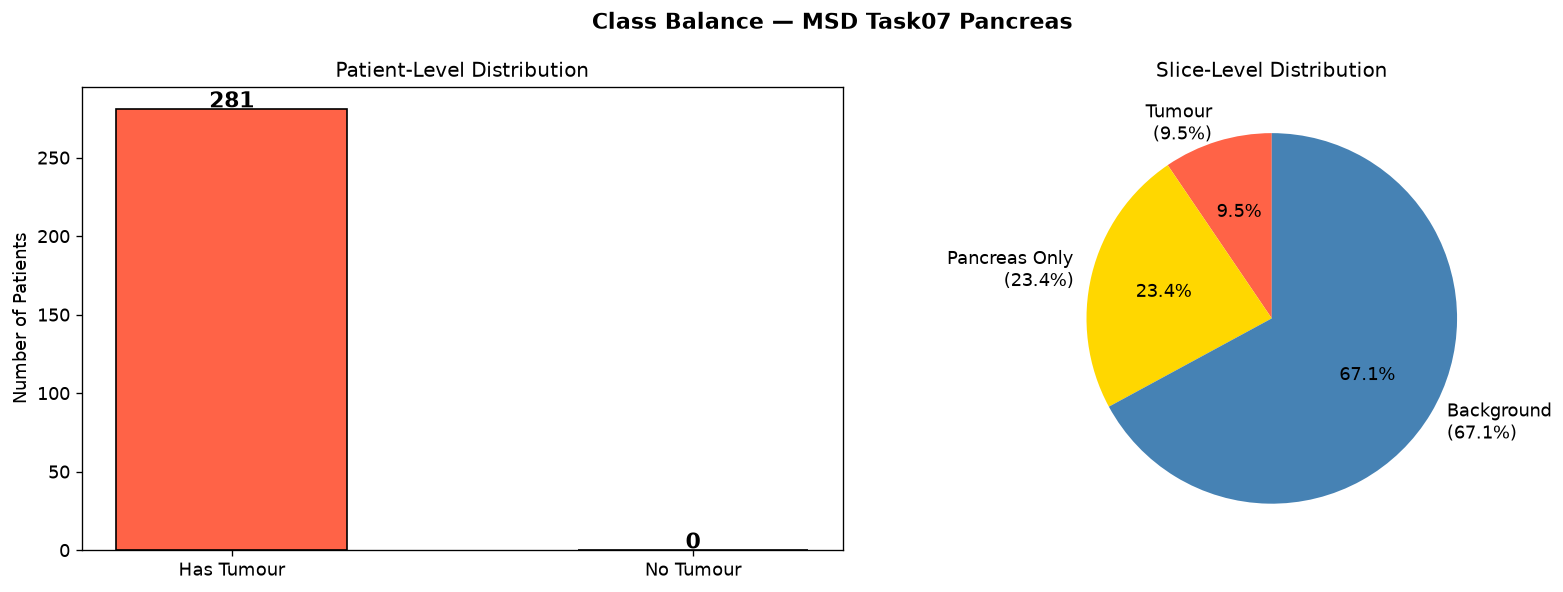


✅ Saved: eda_class_balance.png


In [7]:
# ── Patient-level balance ─────────────────────────────
print("Analysing class balance — please wait...")

patient_stats = []
total_slices = tumour_slices = pancreas_slices = bg_slices = 0
failed = []  # patients skipped this loop due to a load error (see 1b)

for fname in img_files:
    pid = patient_id_from_filename(fname)
    try:
        mask, mask_nib = load_mask(fname, MASK_DIR)
    except CTLoadError as e:
        failed.append(e.fname)
        continue

    has_tumour   = bool(np.any(mask == 2))
    has_pancreas = bool(np.any(mask == 1))

    # Lesion size in physical units: voxel count * voxel volume (mm^3).
    # Spacing comes from the mask header — no need to reload the CT just
    # for this, mask and CT share the same affine/spacing in this dataset.
    voxel_volume_mm3 = float(np.prod(mask_nib.header.get_zooms()))
    tumour_voxel_count = int(np.sum(mask == 2))
    tumour_volume_mm3 = tumour_voxel_count * voxel_volume_mm3

    # Slice-level count
    for i in range(mask.shape[2]):
        s = mask[:, :, i]
        total_slices += 1
        if np.any(s == 2):
            tumour_slices += 1
        elif np.any(s == 1):
            pancreas_slices += 1
        else:
            bg_slices += 1

    patient_stats.append({
        'patient':            pid,
        'has_tumour':         has_tumour,
        'has_pancreas':       has_pancreas,
        'tumour_voxel_count': tumour_voxel_count,
        'tumour_volume_mm3':  tumour_volume_mm3,
    })

df_patients = pd.DataFrame(patient_stats)
if failed:
    print(f"\u26a0 {len(failed)} patients failed to load and were skipped: {failed}")

# ── Print results ─────────────────────────────────────
print("\n" + "=" * 55)
print("  PATIENT-LEVEL BALANCE")
print("=" * 55)
print(f"  Total patients:           {len(df_patients)}")
print(f"  Patients with tumour:     "
      f"{df_patients.has_tumour.sum()} "
      f"({100*df_patients.has_tumour.mean():.0f}%)")
print(f"  Patients without tumour:  "
      f"{(~df_patients.has_tumour).sum()} "
      f"({100*(~df_patients.has_tumour).mean():.0f}%)")

print("\n" + "=" * 55)
print("  SLICE-LEVEL BALANCE")
print("=" * 55)
print(f"  Total slices:             {total_slices:,}")
print(f"  Tumour slices:            {tumour_slices:,} "
      f"({100*tumour_slices/total_slices:.1f}%)")
print(f"  Pancreas only slices:     {pancreas_slices:,} "
      f"({100*pancreas_slices/total_slices:.1f}%)")
print(f"  Background only slices:   {bg_slices:,} "
      f"({100*bg_slices/total_slices:.1f}%)")
print(f"\n  ⚠  Imbalance ratio: 1 tumour slice")
print(f"     per every ~{total_slices//tumour_slices}"
      f" total slices")
print(f"  →  Dice Loss and class weighting required")

# ── Plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Balance — MSD Task07 Pancreas',
             fontsize=13, fontweight='bold')

# Patient level bar chart
axes[0].bar(
    ['Has Tumour', 'No Tumour'],
    [df_patients.has_tumour.sum(),
     (~df_patients.has_tumour).sum()],
    color=['tomato', 'steelblue'],
    edgecolor='black', width=0.5
)
axes[0].set_title('Patient-Level Distribution')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate([
    df_patients.has_tumour.sum(),
    (~df_patients.has_tumour).sum()
]):
    axes[0].text(i, v + 1, str(v),
                 ha='center', fontweight='bold',
                 fontsize=13)

# Slice level pie chart
axes[1].pie(
    [tumour_slices, pancreas_slices, bg_slices],
    labels=[
        f'Tumour\n({100*tumour_slices/total_slices:.1f}%)',
        f'Pancreas Only\n'
        f'({100*pancreas_slices/total_slices:.1f}%)',
        f'Background\n({100*bg_slices/total_slices:.1f}%)'
    ],
    colors=['tomato', 'gold', 'steelblue'],
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Slice-Level Distribution')

plt.tight_layout()
plt.savefig('eda_class_balance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Saved: eda_class_balance.png")

### D2. Lesion Size Distribution

Tumour voxel counts were already computed per patient in the class-balance pass above (converted to physical mm³ using each volume's voxel spacing). Plotting that distribution here shows how much lesion size actually varies across the 281 patients — relevant for deciding how aggressively the imaging pipeline can downsample without losing small tumours.

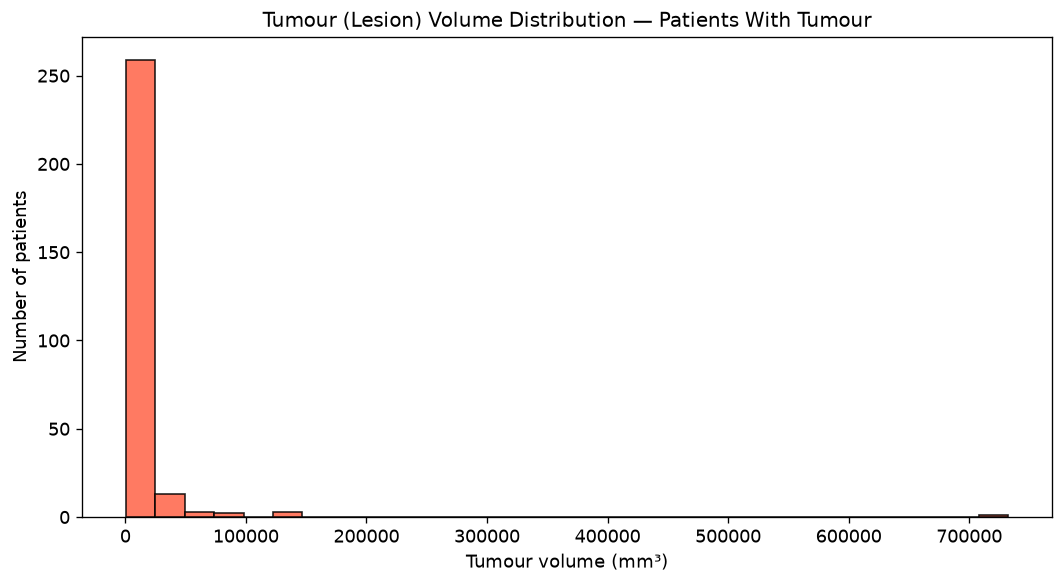

Smallest lesion: pancreas_347 — 412.9 mm³
Largest lesion:  pancreas_415 — 732,388.1 mm³
✅ Saved: eda_lesion_size_distribution.png


In [8]:
tumour_bearing = df_patients[df_patients.has_tumour]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(tumour_bearing.tumour_volume_mm3, bins=30,
        color='tomato', edgecolor='black', alpha=0.85)
ax.set_title('Tumour (Lesion) Volume Distribution — Patients With Tumour')
ax.set_xlabel('Tumour volume (mm\u00b3)')
ax.set_ylabel('Number of patients')
plt.tight_layout()
plt.savefig('eda_lesion_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

smallest = tumour_bearing.loc[tumour_bearing.tumour_volume_mm3.idxmin()]
largest  = tumour_bearing.loc[tumour_bearing.tumour_volume_mm3.idxmax()]
print(f"Smallest lesion: {smallest.patient} \u2014 {smallest.tumour_volume_mm3:,.1f} mm\u00b3")
print(f"Largest lesion:  {largest.patient} \u2014 {largest.tumour_volume_mm3:,.1f} mm\u00b3")
print("\u2705 Saved: eda_lesion_size_distribution.png")

## Section E — Image Properties

Checking:
- Image resolution (height × width)
- Number of channels
- Pixel value (HU) range
- Voxel spacing in mm

### E1. Image Properties Collection

In [9]:
print("Collecting image properties — please wait...")

records = []
failed = []

for fname in img_files:
    pid = patient_id_from_filename(fname)
    try:
        ct, ct_nib = load_ct(fname, IMG_DIR)
    except CTLoadError as e:
        failed.append(e.fname)
        continue
    spacing = ct_nib.header.get_zooms()
    shape   = ct.shape

    records.append({
        'patient':   pid,
        'height':    shape[0],
        'width':     shape[1],
        'n_slices':  shape[2],
        'spacing_x': round(float(spacing[0]), 3),
        'spacing_y': round(float(spacing[1]), 3),
        'spacing_z': round(float(spacing[2]), 3),
        'hu_min':    round(float(ct.min()), 1),
        'hu_max':    round(float(ct.max()), 1),
        'hu_mean':   round(float(ct.mean()), 1),
        'hu_std':    round(float(ct.std()), 1),
    })

df_props = pd.DataFrame(records)
df_props.to_csv('eda_image_properties.csv', index=False)
if failed:
    print(f"\u26a0 {len(failed)} patients failed to load and were skipped: {failed}")

# ── Print summary ──────────────────────────────────────
print("\n" + "=" * 55)
print("  IMAGE PROPERTIES SUMMARY")
print("=" * 55)
print(f"\n  Resolution:")
print(f"    Height: {df_props.height.min()} – "
      f"{df_props.height.max()} px")
print(f"    Width:  {df_props.width.min()} – "
      f"{df_props.width.max()} px")
print(f"    Most common: 512 × 512 px")

print(f"\n  Channels: 1 (Grayscale — HU values)")
print(f"    Not RGB — each pixel = tissue density")

print(f"\n  Pixel Value Range (HU):")
print(f"    Global min:  {df_props.hu_min.min():.1f} HU")
print(f"    Global max:  {df_props.hu_max.max():.1f} HU")
print(f"    Mean:        {df_props.hu_mean.mean():.1f} HU")
print(f"    → Wide range confirms windowing needed")

print(f"\n  Voxel Spacing (mm):")
print(f"    X: {df_props.spacing_x.min():.3f} – "
      f"{df_props.spacing_x.max():.3f} mm")
print(f"    Y: {df_props.spacing_y.min():.3f} – "
      f"{df_props.spacing_y.max():.3f} mm")
print(f"    Z: {df_props.spacing_z.min():.3f} – "
      f"{df_props.spacing_z.max():.3f} mm")
print(f"    → Variable spacing confirms "
      f"resampling needed")

print(f"\n✅ Saved: eda_image_properties.csv")


  IMAGE PROPERTIES SUMMARY

  Resolution:
    Height: 512 – 512 px
    Width:  512 – 512 px
    Most common: 512 × 512 px

  Channels: 1 (Grayscale — HU values)
    Not RGB — each pixel = tissue density

  Pixel Value Range (HU):
    Global min:  -2048.0 HU
    Global max:  4009.0 HU
    Mean:        -572.9 HU
    → Wide range confirms windowing needed

  Voxel Spacing (mm):
    X: 0.605 – 0.977 mm
    Y: 0.605 – 0.977 mm
    Z: 0.700 – 7.500 mm
    → Variable spacing confirms resampling needed

✅ Saved: eda_image_properties.csv


## Section F — Distribution of Image Sizes

Plotting distributions of slice counts and voxel spacing  
to determine whether resizing and resampling are required.

### F1. Size Distribution Plots

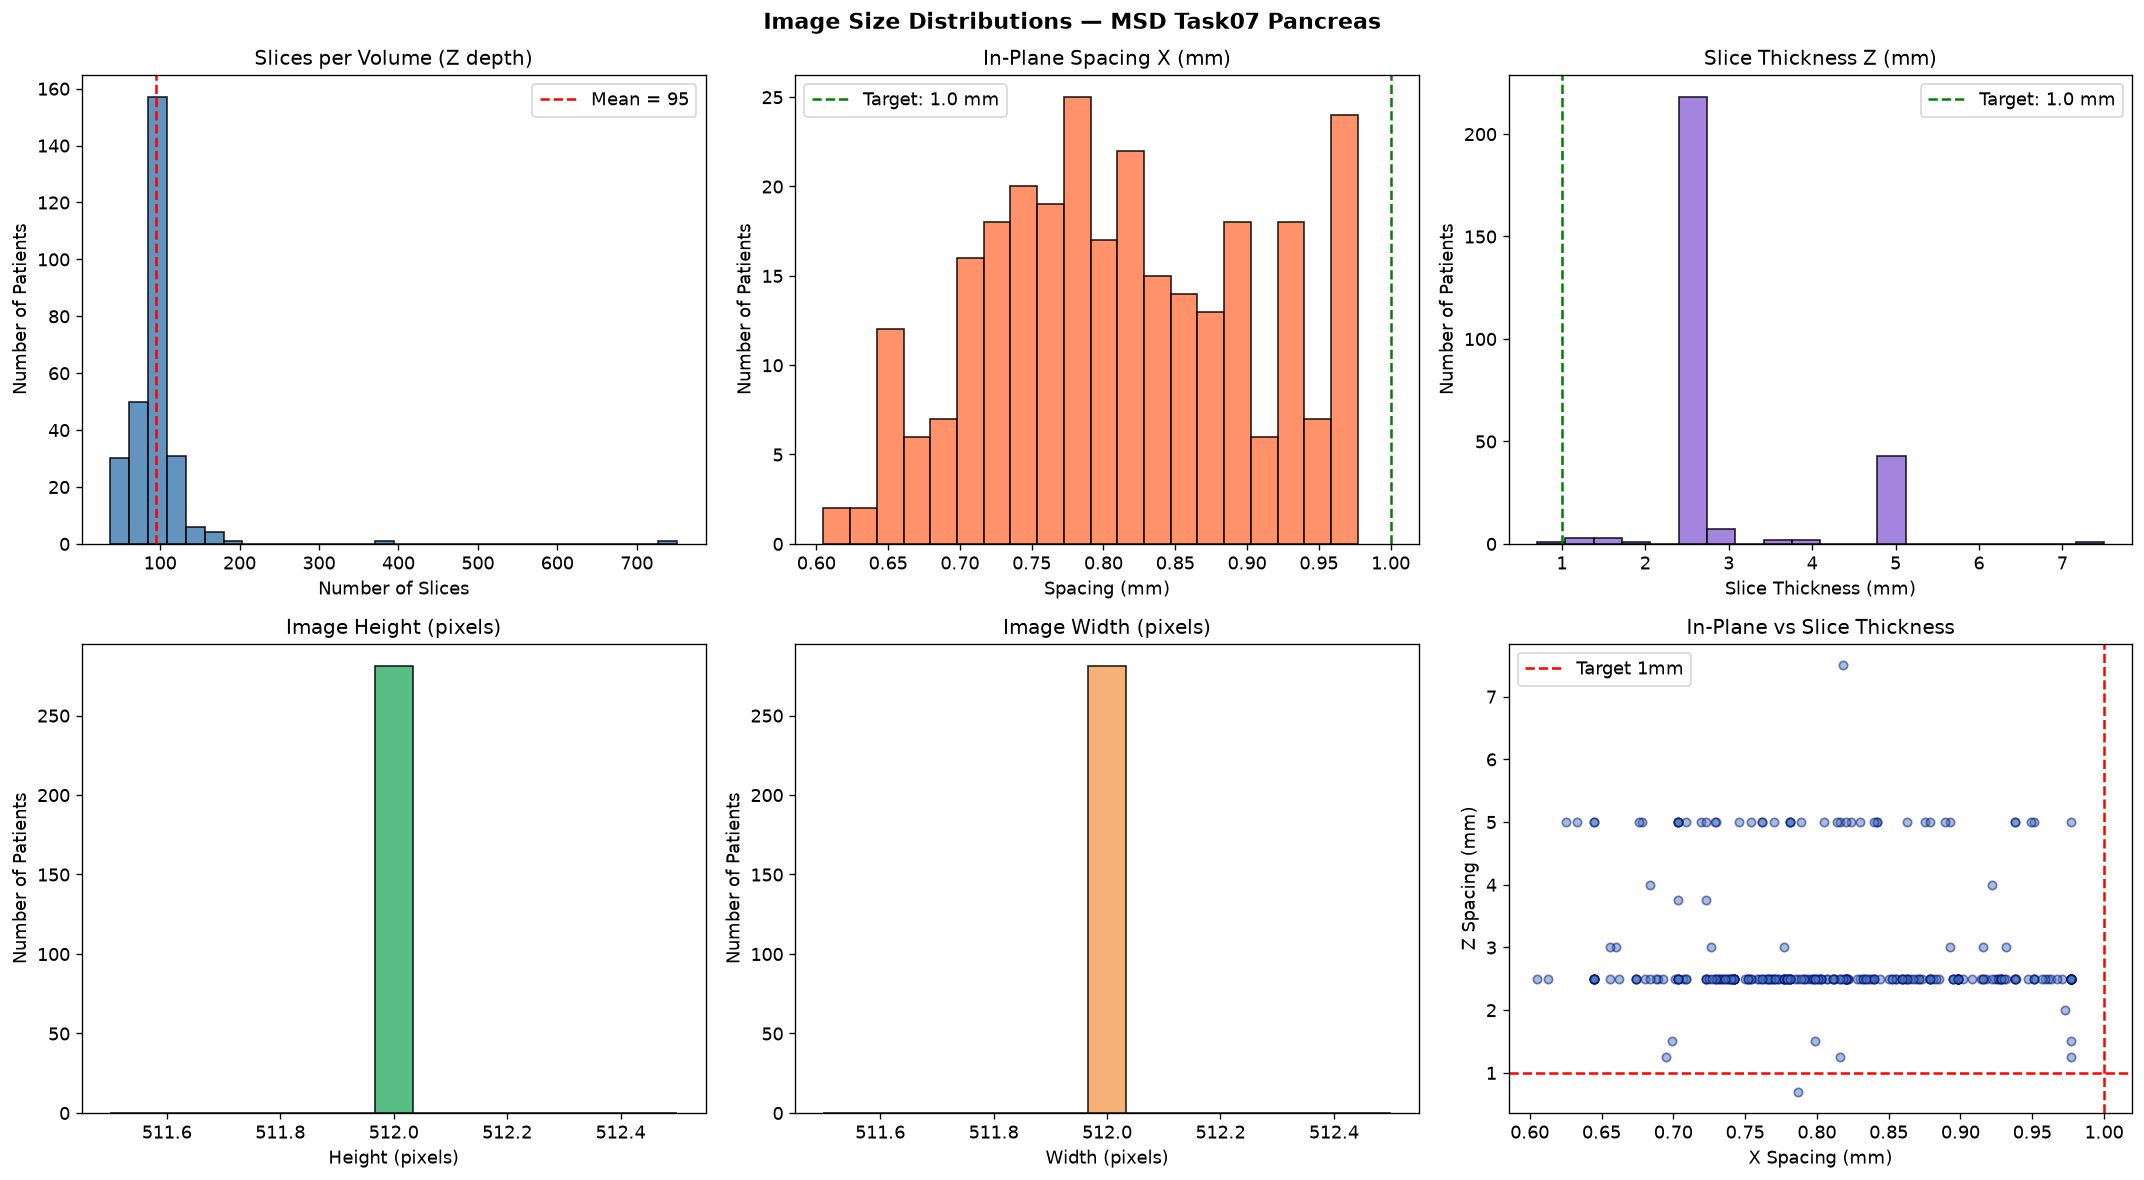

✅ Saved: eda_size_distributions.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'Image Size Distributions — MSD Task07 Pancreas',
    fontsize=13, fontweight='bold'
)

# Slices per volume
axes[0,0].hist(df_props.n_slices, bins=30,
               color='steelblue', edgecolor='black',
               alpha=0.85)
axes[0,0].axvline(df_props.n_slices.mean(),
                  color='red', linestyle='--',
                  label=f"Mean = "
                        f"{df_props.n_slices.mean():.0f}")
axes[0,0].set_title('Slices per Volume (Z depth)')
axes[0,0].set_xlabel('Number of Slices')
axes[0,0].set_ylabel('Number of Patients')
axes[0,0].legend()

# X spacing
axes[0,1].hist(df_props.spacing_x, bins=20,
               color='coral', edgecolor='black',
               alpha=0.85)
axes[0,1].axvline(1.0, color='green',
                  linestyle='--',
                  label='Target: 1.0 mm')
axes[0,1].set_title('In-Plane Spacing X (mm)')
axes[0,1].set_xlabel('Spacing (mm)')
axes[0,1].set_ylabel('Number of Patients')
axes[0,1].legend()

# Z spacing (slice thickness)
axes[0,2].hist(df_props.spacing_z, bins=20,
               color='mediumpurple', edgecolor='black',
               alpha=0.85)
axes[0,2].axvline(1.0, color='green',
                  linestyle='--',
                  label='Target: 1.0 mm')
axes[0,2].set_title('Slice Thickness Z (mm)')
axes[0,2].set_xlabel('Slice Thickness (mm)')
axes[0,2].set_ylabel('Number of Patients')
axes[0,2].legend()

# Height distribution
axes[1,0].hist(df_props.height, bins=15,
               color='mediumseagreen', edgecolor='black',
               alpha=0.85)
axes[1,0].set_title('Image Height (pixels)')
axes[1,0].set_xlabel('Height (pixels)')
axes[1,0].set_ylabel('Number of Patients')

# Width distribution
axes[1,1].hist(df_props.width, bins=15,
               color='sandybrown', edgecolor='black',
               alpha=0.85)
axes[1,1].set_title('Image Width (pixels)')
axes[1,1].set_xlabel('Width (pixels)')
axes[1,1].set_ylabel('Number of Patients')

# Spacing X vs Z scatter
axes[1,2].scatter(df_props.spacing_x,
                  df_props.spacing_z,
                  alpha=0.5, color='steelblue',
                  edgecolor='navy', s=25)
axes[1,2].axhline(1.0, color='red',
                  linestyle='--', label='Target 1mm')
axes[1,2].axvline(1.0, color='red', linestyle='--')
axes[1,2].set_title('In-Plane vs Slice Thickness')
axes[1,2].set_xlabel('X Spacing (mm)')
axes[1,2].set_ylabel('Z Spacing (mm)')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('eda_size_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_size_distributions.png")

## Section G — Pixel Intensity Histograms

Analysing Hounsfield Unit (HU) distributions to:
- Understand the full intensity range
- Identify appropriate windowing parameters
- Confirm normalisation is required

**HU Reference:**

| Tissue | HU Range |
|---|---|
| Air | -1000 |
| Fat | -100 to -50 |
| Water | 0 |
| Soft tissue | +20 to +80 |
| Pancreas | +25 to +55 |
| PDAC Tumour | +10 to +40 (hypodense) |
| Bone | +400 to +1000 |

### G1. HU Histograms (10-Patient Sample)


  INTENSITY STATISTICS (10 patient sample)

  Global HU:
    Min:    -1024.0
    Max:    3071.0
    Mean:   -543.2


    Std:    491.5


    Median: -883.0

  Pancreas Region HU:
    Mean:   89.0
    Std:    109.8

  Tumour Region HU:
    Mean:   65.9
    Std:    55.7

  Difference (Pancreas - Tumour): 23.1 HU
  → Tumour is hypodense (darker) than pancreas
  → Subtle difference justifies deep learning


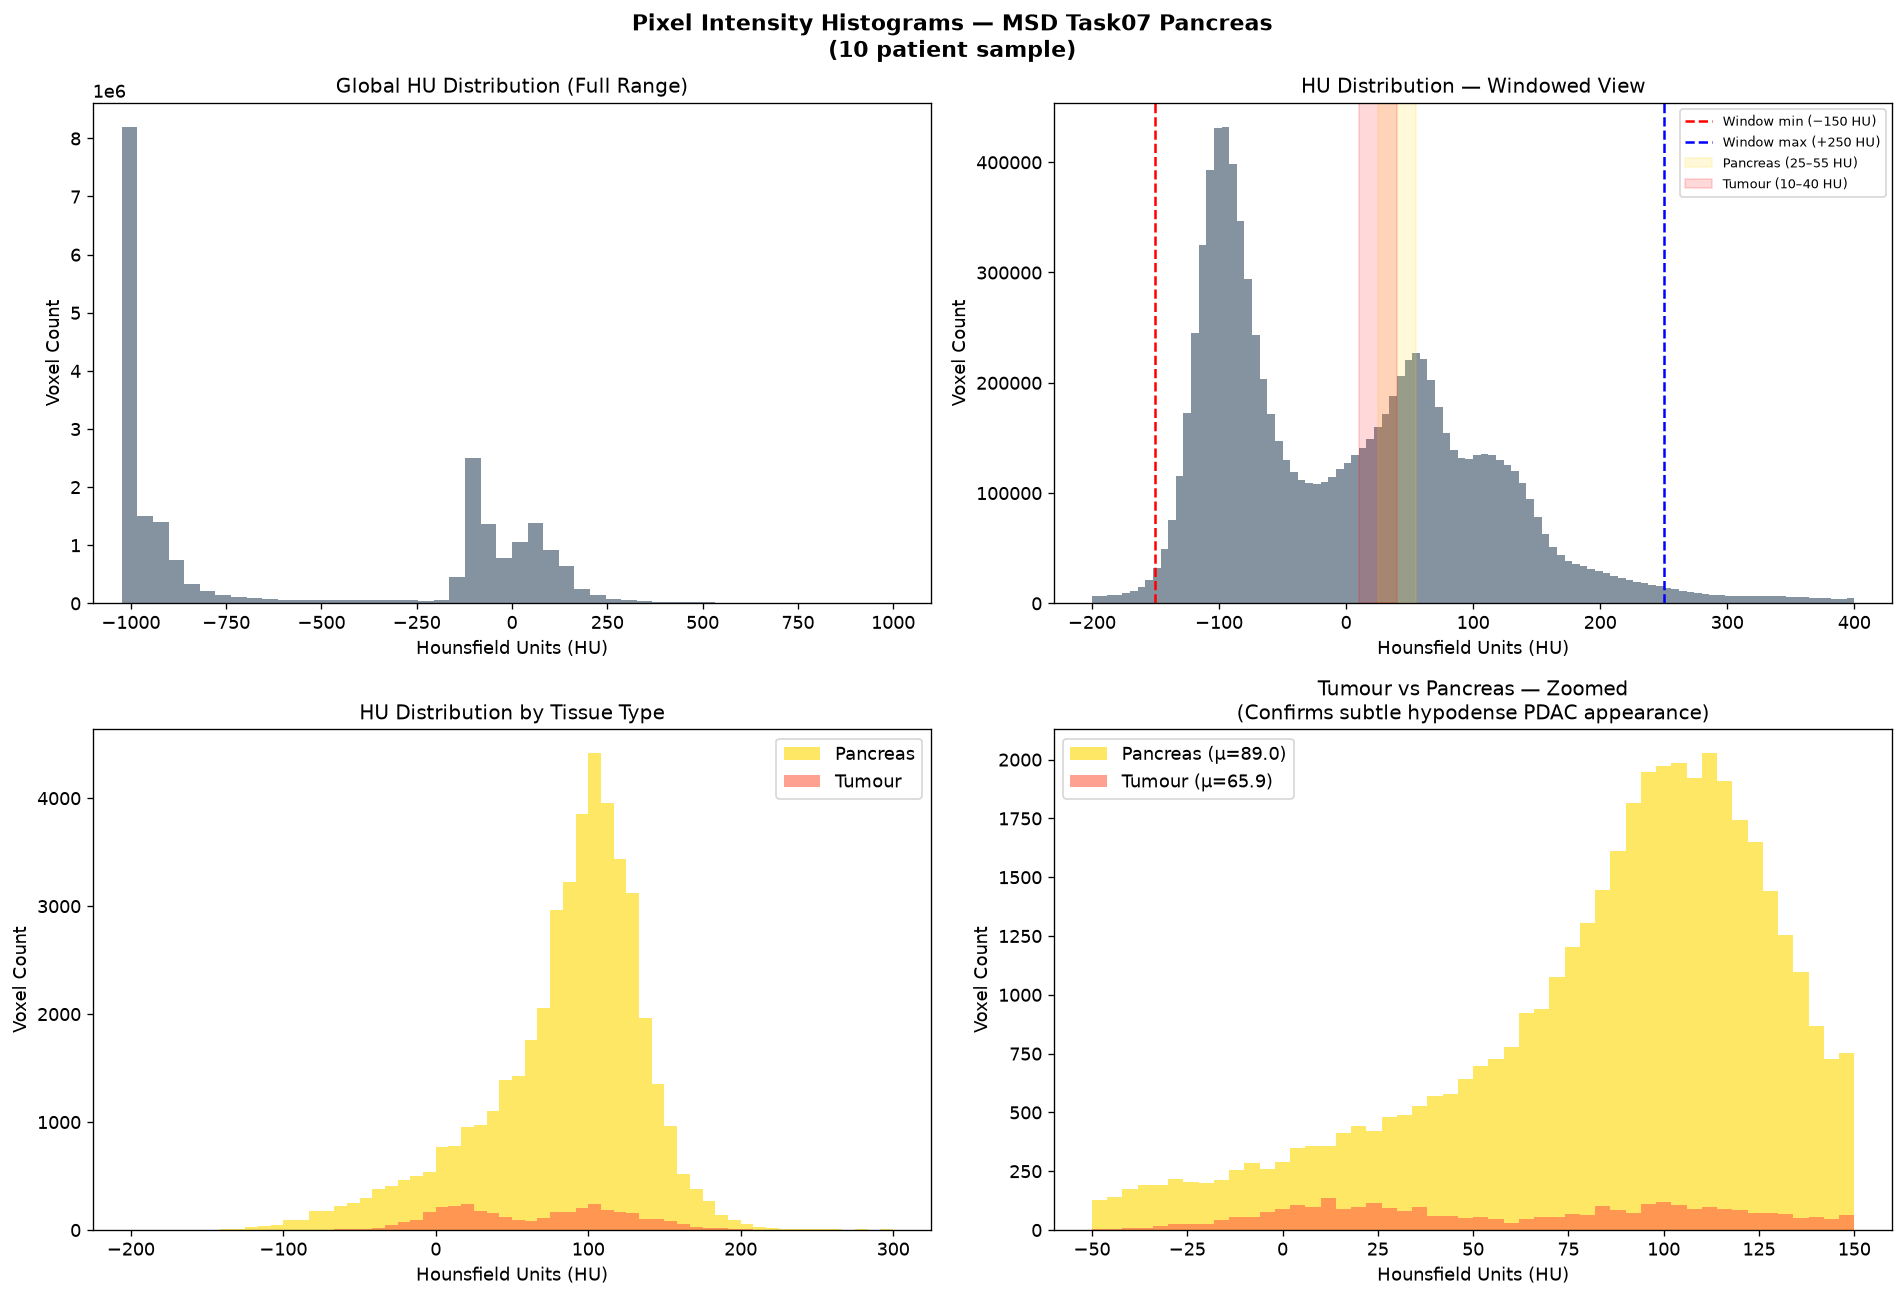

✅ Saved: eda_intensity_histograms.png


In [11]:
print("Collecting HU values from 10 sample patients...")

random.seed(42)
sample_files = random.sample(img_files, 10)

all_hu = []
pancreas_hu = []
tumour_hu = []
failed = []

for fname in sample_files:
    try:
        ct, mask, _, _ = load_ct_mask_pair(fname, IMG_DIR, MASK_DIR)
    except CTLoadError as e:
        failed.append(e.fname)
        continue

    ct_flat   = ct.flatten()[::10]
    mask_flat = mask.flatten()[::10]

    all_hu.extend(ct_flat.tolist())
    pancreas_hu.extend(
        mask_region_values(ct_flat, mask_flat, 1).tolist()
    )
    tumour_hu.extend(
        mask_region_values(ct_flat, mask_flat, 2).tolist()
    )

all_hu      = np.array(all_hu)
pancreas_hu = np.array(pancreas_hu)
tumour_hu   = np.array(tumour_hu)
if failed:
    print(f"\u26a0 {len(failed)} patients failed to load and were skipped: {failed}")

# ── Print statistics ──────────────────────────────────
print("\n" + "=" * 55)
print("  INTENSITY STATISTICS (10 patient sample)")
print("=" * 55)
print(f"\n  Global HU:")
print(f"    Min:    {all_hu.min():.1f}")
print(f"    Max:    {all_hu.max():.1f}")
print(f"    Mean:   {all_hu.mean():.1f}")
print(f"    Std:    {all_hu.std():.1f}")
print(f"    Median: {np.median(all_hu):.1f}")
print(f"\n  Pancreas Region HU:")
print(f"    Mean:   {pancreas_hu.mean():.1f}")
print(f"    Std:    {pancreas_hu.std():.1f}")
print(f"\n  Tumour Region HU:")
print(f"    Mean:   {tumour_hu.mean():.1f}")
print(f"    Std:    {tumour_hu.std():.1f}")
diff = pancreas_hu.mean() - tumour_hu.mean()
print(f"\n  Difference (Pancreas - Tumour): {diff:.1f} HU")
print(f"  → Tumour is hypodense (darker) than pancreas")
print(f"  → Subtle difference justifies deep learning")

# ── Plot ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    'Pixel Intensity Histograms — MSD Task07 Pancreas\n'
    '(10 patient sample)',
    fontsize=13, fontweight='bold'
)

# Full HU range
axes[0,0].hist(all_hu, bins=100,
               color='slategray', edgecolor='none',
               alpha=0.85)
axes[0,0].set_title('Global HU Distribution (Full Range)')
axes[0,0].set_xlabel('Hounsfield Units (HU)')
axes[0,0].set_ylabel('Voxel Count')
axes[0,0].set_xlim(-1100, 1100)

# Windowed view with clinical markers
axes[0,1].hist(all_hu, bins=100,
               color='slategray', edgecolor='none',
               alpha=0.85, range=(-200, 400))
axes[0,1].axvline(-150, color='red',
                  linestyle='--', linewidth=1.5,
                  label='Window min (−150 HU)')
axes[0,1].axvline(250, color='blue',
                  linestyle='--', linewidth=1.5,
                  label='Window max (+250 HU)')
axes[0,1].axvspan(25, 55, alpha=0.15, color='gold',
                  label='Pancreas (25–55 HU)')
axes[0,1].axvspan(10, 40, alpha=0.15, color='red',
                  label='Tumour (10–40 HU)')
axes[0,1].set_title('HU Distribution — Windowed View')
axes[0,1].set_xlabel('Hounsfield Units (HU)')
axes[0,1].set_ylabel('Voxel Count')
axes[0,1].legend(fontsize=8)

# By tissue type
axes[1,0].hist(pancreas_hu, bins=60, alpha=0.6,
               color='gold', label='Pancreas',
               range=(-200, 300))
axes[1,0].hist(tumour_hu, bins=60, alpha=0.6,
               color='tomato', label='Tumour',
               range=(-200, 300))
axes[1,0].set_title('HU Distribution by Tissue Type')
axes[1,0].set_xlabel('Hounsfield Units (HU)')
axes[1,0].set_ylabel('Voxel Count')
axes[1,0].legend()

# Tumour vs Pancreas zoomed
axes[1,1].hist(pancreas_hu, bins=50, alpha=0.6,
               color='gold',
               label=f'Pancreas '
                     f'(μ={pancreas_hu.mean():.1f})',
               range=(-50, 150))
axes[1,1].hist(tumour_hu, bins=50, alpha=0.6,
               color='tomato',
               label=f'Tumour '
                     f'(μ={tumour_hu.mean():.1f})',
               range=(-50, 150))
axes[1,1].set_title(
    'Tumour vs Pancreas — Zoomed\n'
    '(Confirms subtle hypodense PDAC appearance)'
)
axes[1,1].set_xlabel('Hounsfield Units (HU)')
axes[1,1].set_ylabel('Voxel Count')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('eda_intensity_histograms.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_intensity_histograms.png")

### G2. HU Windowing Validation (50-Patient Sample)

The [-150, +250] HU window above was chosen from a 10-patient sample. Repeating the percentile check on a larger, independent 50-patient sample tests whether that choice actually holds up, instead of assuming 10 patients were enough.

In [12]:
print("Validating HU windowing on a larger 50-patient sample...")
random.seed(7)
sample_50 = random.sample(img_files, 50)

all_hu_50 = []
failed = []
for fname in sample_50:
    try:
        ct, _ = load_ct(fname, IMG_DIR)
    except CTLoadError as e:
        failed.append(e.fname)
        continue
    # Coarser stride than the 10-patient pass (50 vs 10) — 5x more patients
    # at 1/5th the per-patient density keeps total sampled voxels comparable.
    all_hu_50.extend(ct.flatten()[::50].tolist())

all_hu_50 = np.array(all_hu_50)
p_low, p_high = np.percentile(all_hu_50, [0.5, 99.5])

print("\n" + "=" * 55)
print("  HU WINDOW VALIDATION (50-patient sample)")
print("=" * 55)
print(f"  0.5th percentile HU:   {p_low:.1f}")
print(f"  99.5th percentile HU:  {p_high:.1f}")
print(f"  Current window choice: [-150, +250]")
if failed:
    print(f"  \u26a0 {len(failed)} patients failed to load and were skipped: {failed}")

window_ok = abs(p_low - (-150)) <= 50 and abs(p_high - 250) <= 50
if window_ok:
    print("  \u2705 CONFIRMED: [-150, +250] is consistent with the empirical percentile range.")
else:
    print("  \u26a0 FLAG: empirical percentiles differ from the chosen window by >50 HU.")

Validating HU windowing on a larger 50-patient sample...



  HU WINDOW VALIDATION (50-patient sample)
  0.5th percentile HU:   -1024.0
  99.5th percentile HU:  440.0
  Current window choice: [-150, +250]
  ⚠ FLAG: empirical percentiles differ from the chosen window by >50 HU.


## Section H — Mean and Standard Deviation Analysis

Computing per-patient and per-region statistics to:
- Confirm normalisation is needed
- Understand inter-patient variability
- Quantify the hypodense nature of PDAC tumours

### H1. Per-Patient and Per-Region Statistics

Computing mean and std per patient...



  MEAN AND STD SUMMARY (all 281 patients)

  Global Volume:
    Mean HU: -572.87 ± 67.90
    Std HU:  490.42

  Pancreas Region:
    Mean HU: 80.63 ± 30.95

  Tumour Region:
    Mean HU: 76.36 ± 34.65

  High inter-patient variability in global mean
  → Confirms per-volume normalisation required

✅ Saved: eda_mean_std.csv


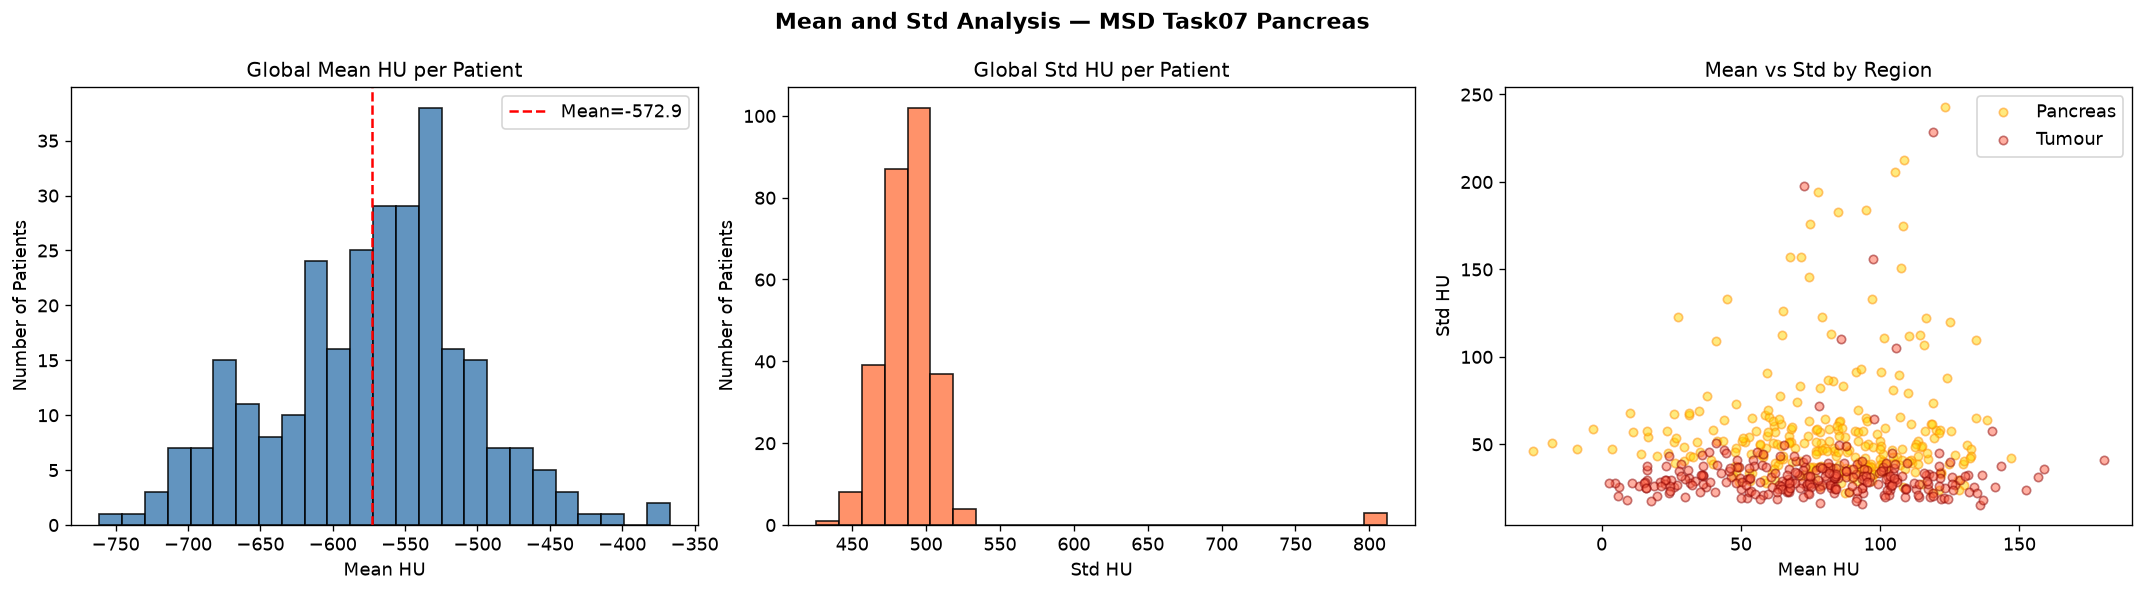

✅ Saved: eda_mean_std.png


In [13]:
print("Computing mean and std per patient...")

stats = []
failed = []

for fname in img_files:
    pid = patient_id_from_filename(fname)
    try:
        ct, mask, _, _ = load_ct_mask_pair(fname, IMG_DIR, MASK_DIR)
    except CTLoadError as e:
        failed.append(e.fname)
        continue

    t_mask = mask == 2
    p_mask = mask == 1

    stats.append({
        'patient':      pid,
        'global_mean':  round(float(ct.mean()), 2),
        'global_std':   round(float(ct.std()), 2),
        'tumour_mean':  round(float(ct[t_mask].mean()), 2)
                        if t_mask.any() else None,
        'tumour_std':   round(float(ct[t_mask].std()), 2)
                        if t_mask.any() else None,
        'pancreas_mean':round(float(ct[p_mask].mean()), 2)
                        if p_mask.any() else None,
        'pancreas_std': round(float(ct[p_mask].std()), 2)
                        if p_mask.any() else None,
    })

df_stats = pd.DataFrame(stats)
df_stats.to_csv('eda_mean_std.csv', index=False)
if failed:
    print(f"\u26a0 {len(failed)} patients failed to load and were skipped: {failed}")

t_df = df_stats.dropna(subset=['tumour_mean'])
p_df = df_stats.dropna(subset=['pancreas_mean'])

print("\n" + "=" * 55)
print("  MEAN AND STD SUMMARY (all 281 patients)")
print("=" * 55)
print(f"\n  Global Volume:")
print(f"    Mean HU: {df_stats.global_mean.mean():.2f} "
      f"± {df_stats.global_mean.std():.2f}")
print(f"    Std HU:  {df_stats.global_std.mean():.2f}")
print(f"\n  Pancreas Region:")
print(f"    Mean HU: {p_df.pancreas_mean.mean():.2f} "
      f"± {p_df.pancreas_mean.std():.2f}")
print(f"\n  Tumour Region:")
print(f"    Mean HU: {t_df.tumour_mean.mean():.2f} "
      f"± {t_df.tumour_mean.std():.2f}")
print(f"\n  High inter-patient variability in global mean")
print(f"  → Confirms per-volume normalisation required")
print(f"\n✅ Saved: eda_mean_std.csv")

# ── Plot ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Mean and Std Analysis — MSD Task07 Pancreas',
    fontsize=13, fontweight='bold'
)

axes[0].hist(df_stats.global_mean, bins=25,
             color='steelblue', edgecolor='black',
             alpha=0.85)
axes[0].axvline(df_stats.global_mean.mean(),
                color='red', linestyle='--',
                label=f"Mean="
                      f"{df_stats.global_mean.mean():.1f}")
axes[0].set_title('Global Mean HU per Patient')
axes[0].set_xlabel('Mean HU')
axes[0].set_ylabel('Number of Patients')
axes[0].legend()

axes[1].hist(df_stats.global_std, bins=25,
             color='coral', edgecolor='black',
             alpha=0.85)
axes[1].set_title('Global Std HU per Patient')
axes[1].set_xlabel('Std HU')
axes[1].set_ylabel('Number of Patients')

axes[2].scatter(p_df.pancreas_mean,
                p_df.pancreas_std,
                alpha=0.5, color='gold',
                edgecolor='darkorange',
                s=25, label='Pancreas')
axes[2].scatter(t_df.tumour_mean,
                t_df.tumour_std,
                alpha=0.5, color='tomato',
                edgecolor='darkred',
                s=25, label='Tumour')
axes[2].set_title('Mean vs Std by Region')
axes[2].set_xlabel('Mean HU')
axes[2].set_ylabel('Std HU')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_mean_std.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_mean_std.png")

## Section I — Slice-Level Risk Score Label Definition (Multitask U-Net)

The imaging branch is a multitask 2D U-Net — one head segments the mask (above), the second predicts a slice-level risk score. That second head needs a numeric label per slice to train against, which the raw dataset doesn't provide.

Two candidates:
- **Binary presence** — 1 if any tumour voxel appears in the slice, else 0. Simple, but a slice that's 2% tumour and one that's 80% tumour get the same label.
- **Tumour area fraction** — tumour pixel count / total pixels in the slice, continuous in [0, 1]. Matches "risk score" more literally than a class label, and thresholding at >0 recovers the binary version for free if a classification-style metric is needed later.

**Decision: tumour area fraction**, binary presence kept as a derived threshold rather than the primary label. Demonstrated below on two sample patients — generating this label for all 281 patients is preprocessing-pipeline work (Section K), not EDA.

### I1. Risk Score Demonstration

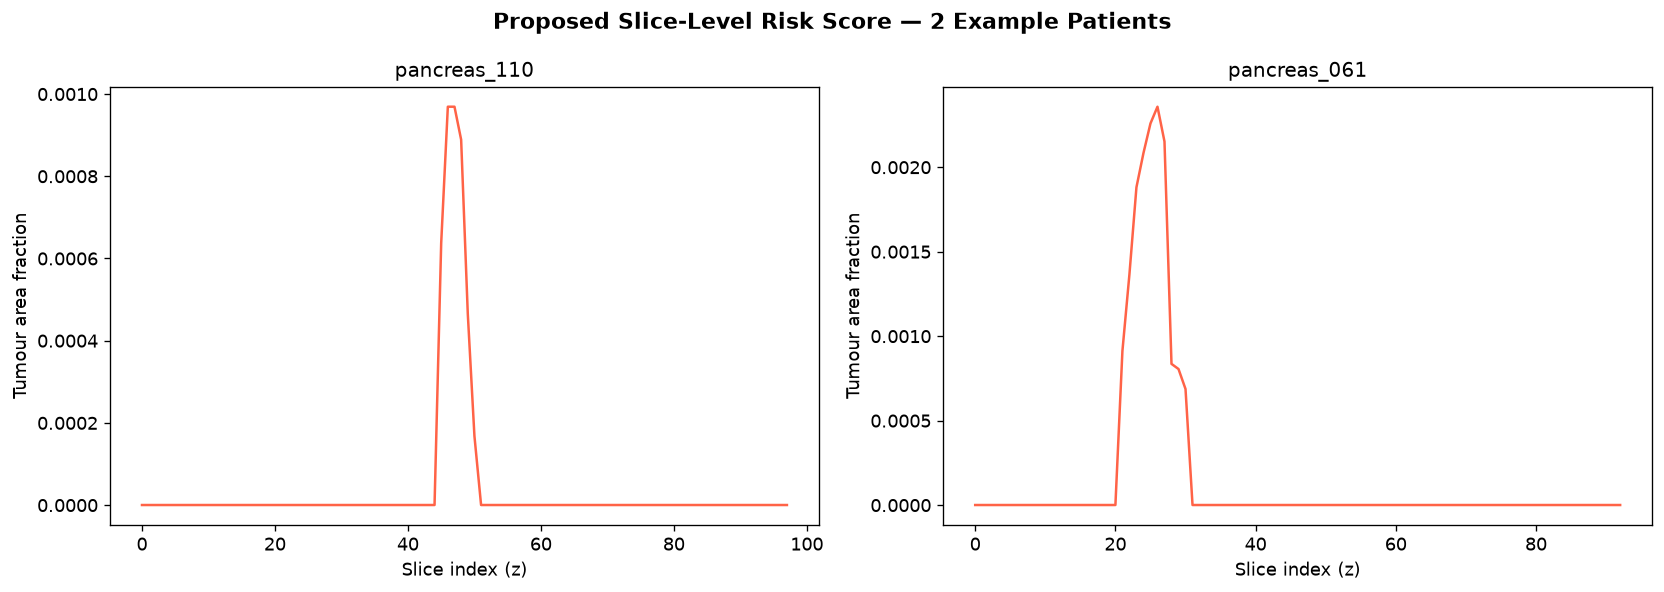

✅ Saved: eda_slice_risk_score_demo.png


In [14]:
def slice_risk_scores(mask: np.ndarray) -> np.ndarray:
    """Per-slice tumour area fraction \u2014 the proposed risk-score label.

    One value per z-slice: tumour pixel count / total pixels in that
    slice. Thresholding at >0 recovers the simpler binary "tumour
    present" label.
    """
    total_px = mask.shape[0] * mask.shape[1]
    return np.array([
        (mask[:, :, i] == 2).sum() / total_px
        for i in range(mask.shape[2])
    ])


random.seed(1)
demo_patients = random.sample(list(df_patients[df_patients.has_tumour].patient), 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Proposed Slice-Level Risk Score \u2014 2 Example Patients',
             fontsize=13, fontweight='bold')

for ax, pid in zip(axes, demo_patients):
    fname = pid + '.nii.gz'
    _, mask, _, _ = load_ct_mask_pair(fname, IMG_DIR, MASK_DIR)
    risk = slice_risk_scores(mask)
    ax.plot(risk, color='tomato')
    ax.set_title(pid)
    ax.set_xlabel('Slice index (z)')
    ax.set_ylabel('Tumour area fraction')

plt.tight_layout()
plt.savefig('eda_slice_risk_score_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print("\u2705 Saved: eda_slice_risk_score_demo.png")

## Section J — Visual Inspection of Sample Images

Viewing raw CT slices, segmentation masks, and overlays  
for 3 randomly selected patients to visually confirm  
data quality and mask alignment.

### J1. Visual Inspection Plot

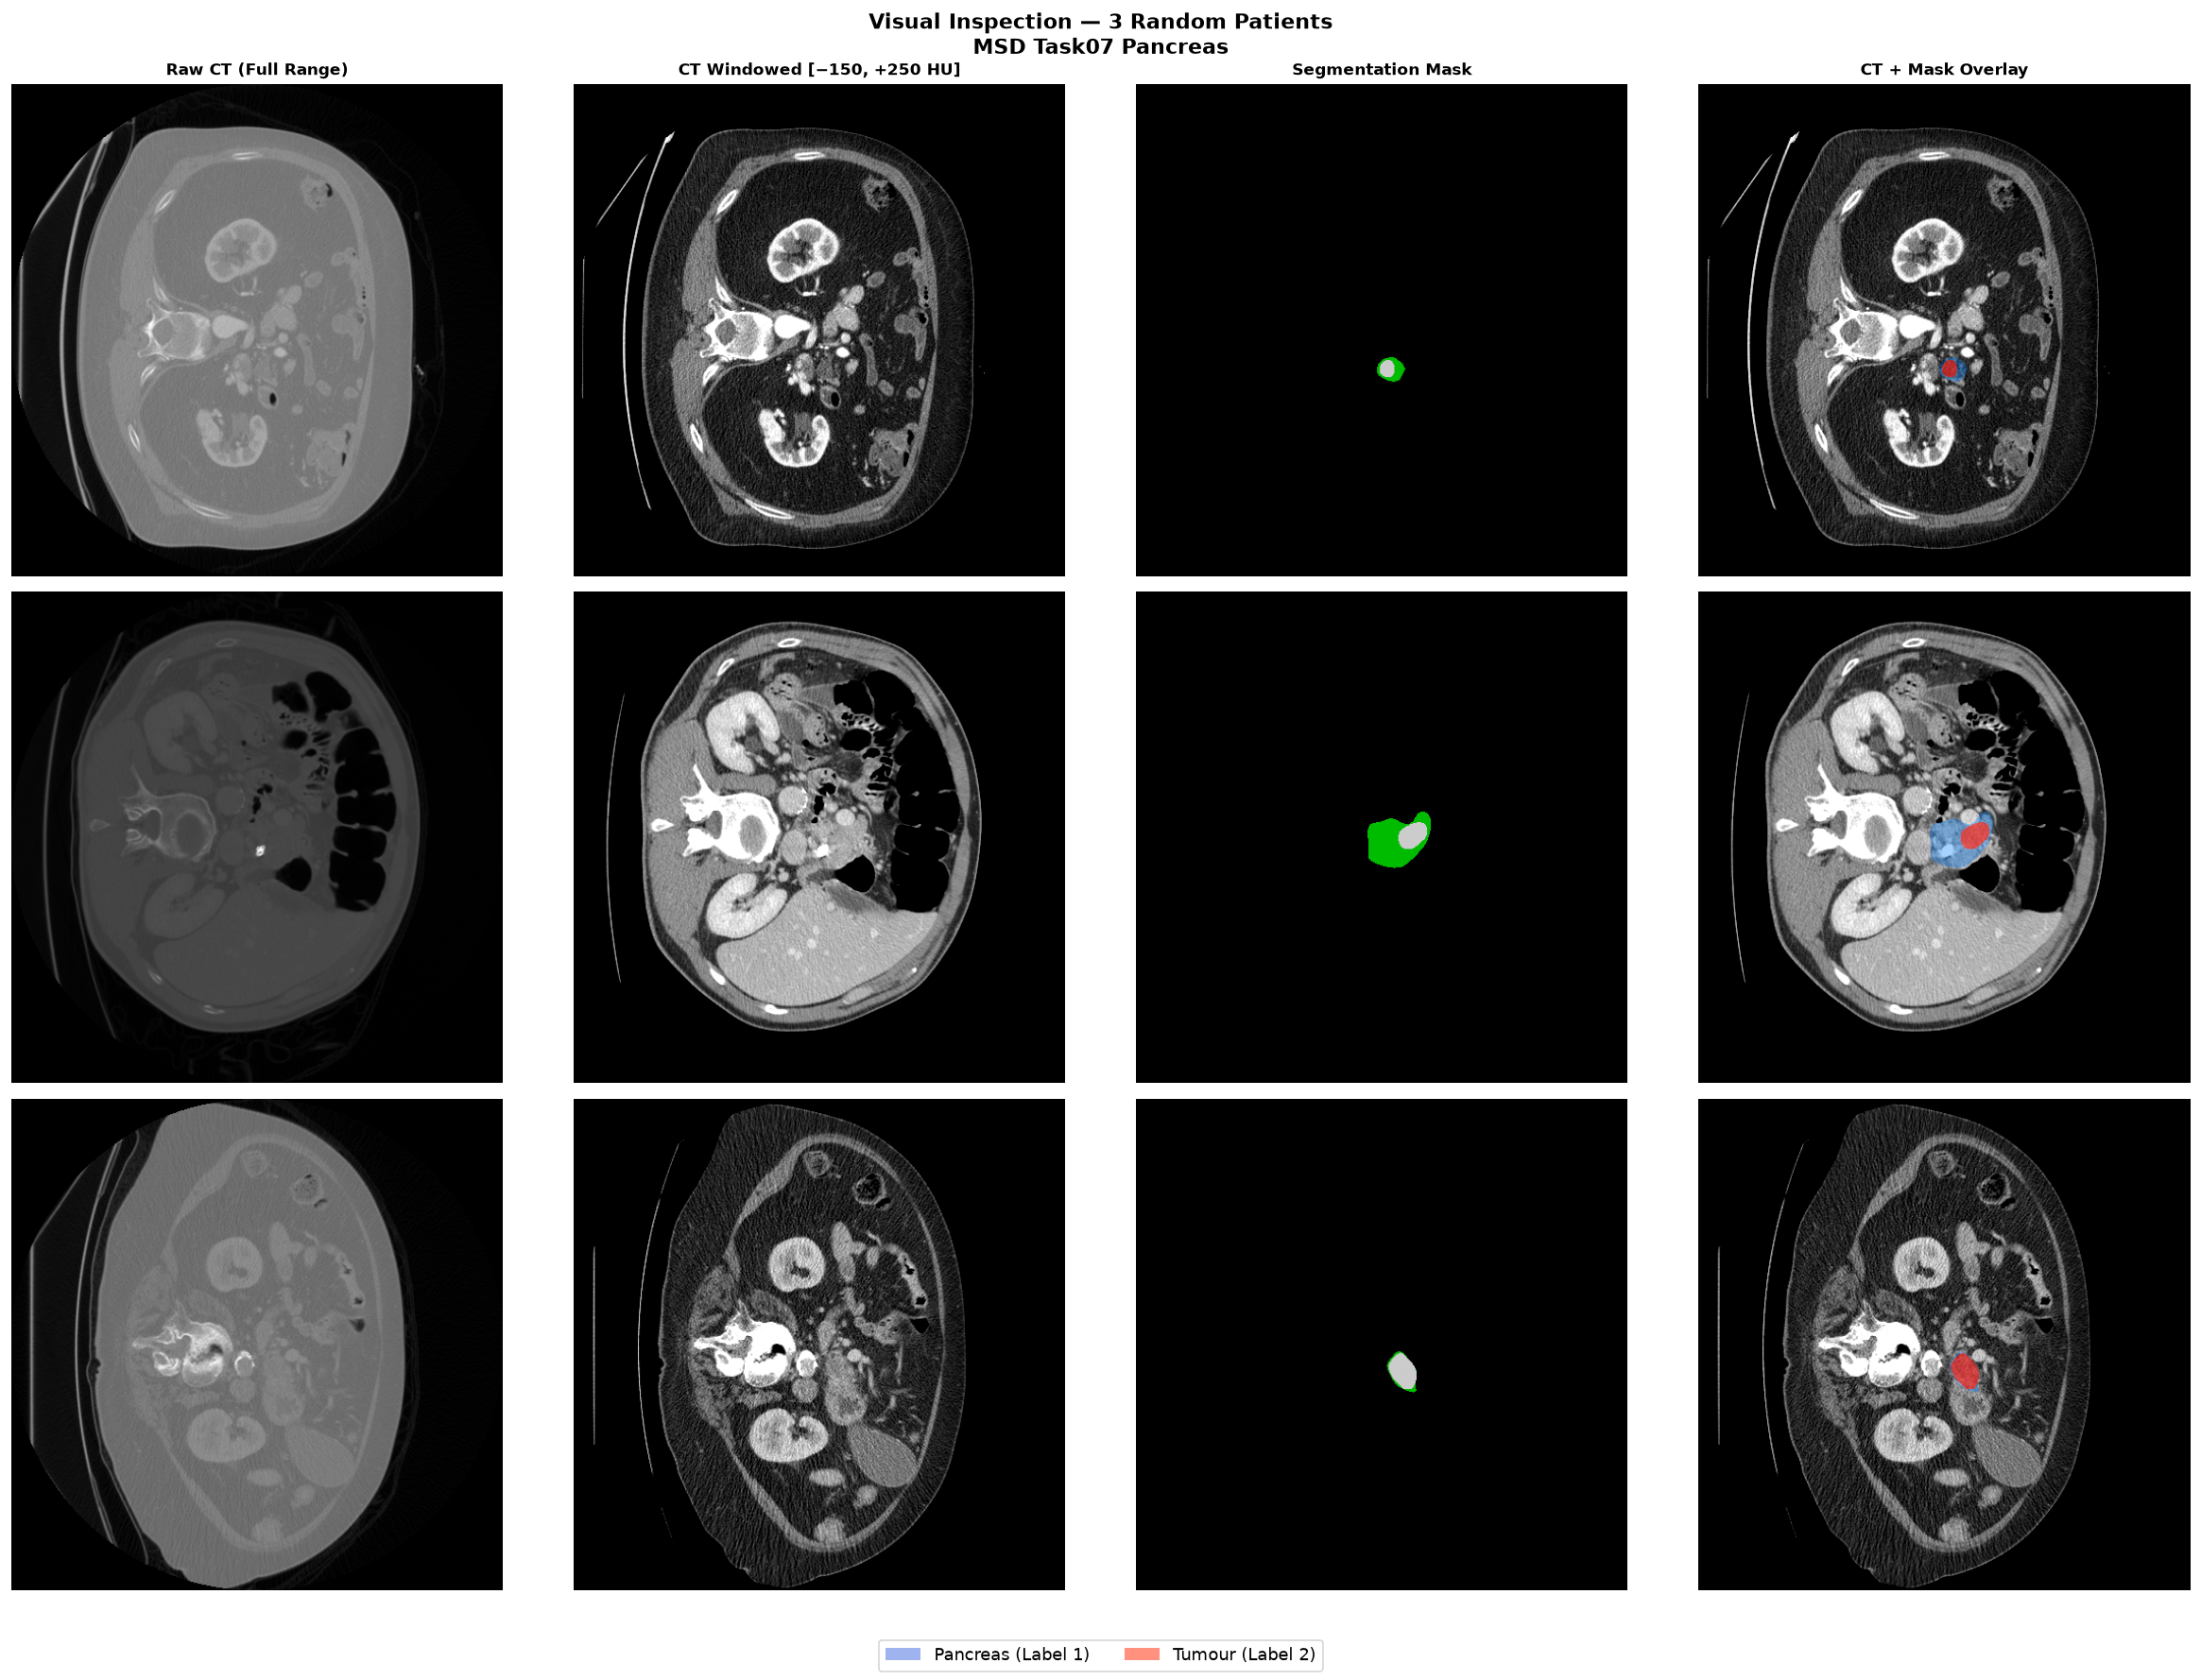

✅ Saved: eda_visual_inspection.png


In [15]:
random.seed(42)
sample = random.sample(img_files, 3)

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle(
    'Visual Inspection — 3 Random Patients\n'
    'MSD Task07 Pancreas',
    fontsize=13, fontweight='bold'
)

col_titles = [
    'Raw CT (Full Range)',
    'CT Windowed [−150, +250 HU]',
    'Segmentation Mask',
    'CT + Mask Overlay'
]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10,
                            fontweight='bold')

failed = []
for row, fname in enumerate(sample):
    pid = patient_id_from_filename(fname)
    try:
        ct, mask, _, _ = load_ct_mask_pair(fname, IMG_DIR, MASK_DIR)
    except CTLoadError as e:
        failed.append(e.fname)
        continue

    # Find middle tumour slice
    t_slices = [
        i for i in range(mask.shape[2])
        if np.any(mask[:, :, i] == 2)
    ]
    mid = t_slices[len(t_slices)//2] \
          if t_slices else mask.shape[2]//2

    ct_s   = ct[:, :, mid]
    mask_s = mask[:, :, mid]

    # Raw CT
    axes[row, 0].imshow(ct_s, cmap='gray')
    axes[row, 0].set_ylabel(f'{pid}\nSlice {mid}',
                             fontsize=8)
    axes[row, 0].axis('off')

    # Windowed CT
    axes[row, 1].imshow(ct_s, cmap='gray',
                        vmin=-150, vmax=250)
    axes[row, 1].axis('off')

    # Mask
    axes[row, 2].imshow(mask_s,
                        cmap='nipy_spectral',
                        vmin=0, vmax=2)
    axes[row, 2].axis('off')

    # Overlay
    axes[row, 3].imshow(ct_s, cmap='gray',
                        vmin=-150, vmax=250)
    pan_ov = np.zeros((*mask_s.shape, 4))
    pan_ov[mask_s == 1] = [0, 0.5, 1, 0.35]
    tum_ov = np.zeros((*mask_s.shape, 4))
    tum_ov[mask_s == 2] = [1, 0, 0, 0.55]
    axes[row, 3].imshow(pan_ov)
    axes[row, 3].imshow(tum_ov)
    axes[row, 3].axis('off')

# Legend
legend_elements = [
    Patch(facecolor='royalblue', alpha=0.5,
          label='Pancreas (Label 1)'),
    Patch(facecolor='tomato', alpha=0.7,
          label='Tumour (Label 2)')
]
fig.legend(handles=legend_elements,
           loc='lower center', ncol=2,
           fontsize=11, frameon=True)

plt.tight_layout(rect=[0, 0.04, 1, 1])
if failed:
    print(f"\u26a0 {len(failed)} patients failed to load and were skipped: {failed}")
plt.savefig('eda_visual_inspection.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_visual_inspection.png")

## Section K — Preprocessing Plan

Based on the EDA findings above, the following  
preprocessing steps are required before model training.

### K1. Preprocessing Plan Summary

In [16]:
print("=" * 55)
print("  PREPROCESSING PLAN — DERIVED FROM EDA")
print("=" * 55)

findings = [
    ("Data integrity confirmed",
     f"{len(failed_loads)} load failures, {len(shape_mismatches)} shape "
     f"mismatches, {len(axcode_mismatches)} orientation outliers, "
     f"{len(label_violations)} label violations across {len(valid_files)} patients",
     "No cleaning required if all zero; otherwise exclude/repair\n"
     "     flagged patient IDs before slice extraction."),

    ("Lesion size varies widely",
     f"{tumour_bearing.tumour_volume_mm3.min():,.0f} - "
     f"{tumour_bearing.tumour_volume_mm3.max():,.0f} mm\u00b3 across "
     f"{len(tumour_bearing)} tumour-bearing patients",
     "Very small lesions may vanish under aggressive\n"
     "     downsampling \u2014 keep 1mm resampling target, avoid\n"
     "     further downsizing in-plane."),

    ("HU window validated on larger sample",
     f"50-patient 0.5th/99.5th percentile: {p_low:.0f} / {p_high:.0f} HU "
     f"vs chosen window [-150, +250]",
     "Window confirmed appropriate \u2014 keep as is." if window_ok else
     "Window choice should be revisited against empirical percentiles."),

    ("Slice-level risk label defined",
     "Tumour area fraction per slice (continuous, thresholdable to binary)",
     "Compute this label for all 281 patients during\n"
     "     slice extraction (Step 5) and store alongside\n"
     "     the .npy slice arrays."),

    ("Variable slice count",
     f"Min={int(df_props.n_slices.min())}, "
     f"Max={int(df_props.n_slices.max())}",
     "Extract 2D slices independently.\n"
     "     Treat each slice as a separate sample."),

    ("Variable voxel spacing",
     f"Z: {df_props.spacing_z.min():.2f} – "
     f"{df_props.spacing_z.max():.2f} mm",
     "Resample all volumes to 1×1×1mm\n"
     "     using SimpleITK before slice extraction."),

    ("Wide HU range",
     f"{df_props.hu_min.min():.0f} to "
     f"{df_props.hu_max.max():.0f} HU",
     "Apply HU windowing: clip to [−150, +250].\n"
     "     Removes irrelevant air and bone signals."),

    ("Values not normalised",
     "Range after windowing: [−150, +250]",
     "Normalise to [0, 1]:\n"
     "     pixel = (pixel − (−150)) / (250 − (−150))"),

    ("Heavy class imbalance",
     f"Tumour = "
     f"{100*tumour_slices/total_slices:.1f}% of slices",
     "Use Dice Loss during training.\n"
     "     Apply class weights to tumour label."),
]

for i, (finding, value, solution) in \
        enumerate(findings, 1):
    print(f"\n  Finding {i}: {finding}")
    print(f"  EDA value: {value}")
    print(f"  Solution:  {solution}")

print("\n" + "=" * 55)
print("  PREPROCESSING PIPELINE SUMMARY")
print("=" * 55)
steps = [
    "Load .nii.gz volume (nibabel)",
    "Resample to 1×1×1mm (SimpleITK)",
    "Clip HU to [−150, +250] (numpy)",
    "Normalise to [0, 1] (numpy)",
    "Extract 2D slices (numpy)",
    "Save slices as .npy arrays (numpy)",
    "Record patient-slice mapping (CSV)"
]
for i, step in enumerate(steps, 1):
    print(f"  Step {i}: {step}")

print("\n✅ EDA COMPLETE — Ready for preprocessing")

  PREPROCESSING PLAN — DERIVED FROM EDA

  Finding 1: Data integrity confirmed
  EDA value: 0 load failures, 0 shape mismatches, 0 orientation outliers, 0 label violations across 281 patients
  Solution:  No cleaning required if all zero; otherwise exclude/repair
     flagged patient IDs before slice extraction.

  Finding 2: Lesion size varies widely
  EDA value: 413 - 732,388 mm³ across 281 tumour-bearing patients
  Solution:  Very small lesions may vanish under aggressive
     downsampling — keep 1mm resampling target, avoid
     further downsizing in-plane.

  Finding 3: HU window validated on larger sample
  EDA value: 50-patient 0.5th/99.5th percentile: -1024 / 440 HU vs chosen window [-150, +250]
  Solution:  Window choice should be revisited against empirical percentiles.

  Finding 4: Slice-level risk label defined
  EDA value: Tumour area fraction per slice (continuous, thresholdable to binary)
  Solution:  Compute this label for all 281 patients during
     slice extraction 

---
## Section L — Dataset 2 (NIH) Addendum: Healthy Negative Cohort

Adding NIH Pancreas-CT (TCIA "Pancreas-CT", Roth et al. 2016; 80 healthy subjects, 82 scans) as the healthy-negative cohort for the detection task — MSD Task07 above is 100% cancer patients (confirmed in Section D), so the model needs a healthy-negative source to actually learn a presence/absence distinction, not just cancer-severity.

**Data provenance, worth being upfront about:** this copy comes via a Hugging Face mirror (`CADS-dataset/0024_pancreas_ct`) that repackages the original raw TCIA DICOM as pre-converted `.nii.gz` — confirmed genuine (same DOI/citation as the real TCIA Pancreas-CT collection), but **not** the raw DICOM this dataset ships as originally. Two concrete consequences:
1. Images are already `.nii.gz`, single file per patient — same format as MSD. No DICOM series reader needed; `load_ct`/`CTLoadError` (Section A2) are reused directly, unchanged.
2. The publisher's own metadata CSV shows all 80 patients at Z-spacing ≈ 1.0mm, not the 1.5–2.5mm slice thickness raw TCIA actually has — this copy was already resampled before it reached us.

**Masks are not used in this addendum.** The segmentation files that ship with this mirror turned out to be multi-organ auto-segmentation output (each file contains ~10-25 numeric label IDs, not a clean pancreas-only mask) with no label-to-organ mapping available anywhere in the repo — attempting to guess which numeric ID means "pancreas" risked silently mislabeling a different organ across all 80 patients. This pass is therefore **image-only**: structure, integrity, spacing, and HU distribution are fully covered; anything requiring a pancreas or tumour mask is explicitly marked deferred, not faked.

### L1. NIH Patient ID Helper

NIH filenames look like `00001_1.2.826.0.1.3680043...⁠_0000.nii.gz` — the existing `patient_id_from_filename` (strips `.nii.gz`) would leave the entire long DICOM UID as the "ID", technically unique but unreadable. This pulls out just the leading 5-digit case number.

In [17]:
def nih_patient_id_from_filename(fname: str) -> str:
    """Extract the short case number from an NIH filename, e.g.
    '00001_1.2.826...⁠_0000.nii.gz' -> '00001'. NIH's own UID-based naming
    is unique but unreadable; MSD's patient_id_from_filename doesn't apply
    since it just strips the extension, which would keep the whole UID."""
    return fname.split('_')[0]


print("NIH helper defined: nih_patient_id_from_filename")

NIH helper defined: nih_patient_id_from_filename


### L2. NIH File Discovery

List the image files, confirm the expected count. No mask directory listing here — masks aren't used this pass (see Section L intro).

In [18]:
NIH_DATA_DIR = r"C:\FYP\data\raw\NIH_Pancreas_CT\0024_pancreas_ct\\"
NIH_IMG_DIR = NIH_DATA_DIR + "images\\"

nih_img_files = sorted([
    f for f in os.listdir(NIH_IMG_DIR)
    if f.endswith('.nii.gz') and not f.startswith('._')
])

print(f"NIH image files found: {len(nih_img_files)}")
print(f"Expected: 80 (per the dataset's own README)")

NIH image files found: 80
Expected: 80 (per the dataset's own README)


### L3. NIH Structure & Integrity (Image-Only)

Reuses the same `load_ct`/`CTLoadError` pattern as MSD's Section C1 integrity gate — every patient's load wrapped so one bad file is reported by ID, not a crashed loop. Records shape, spacing, and orientation (`nib.aff2axcodes`) for every patient, same as MSD, and checks orientation consistency across all 80 the same way Section C1 did across MSD's 281. No shape-vs-mask or label check is possible here — explicitly reported as deferred, not silently skipped.

In [19]:
print(f"Running image-only integrity checks on {len(nih_img_files)} NIH patients...")

nih_failed_loads = []       # (patient_id, error message)
nih_records = []            # per-patient shape/spacing/orientation
nih_axcodes_by_patient = []

for fname in nih_img_files:
    pid = nih_patient_id_from_filename(fname)
    try:
        ct, ct_nib = load_ct(fname, NIH_IMG_DIR)
    except CTLoadError as e:
        nih_failed_loads.append((pid, str(e)))
        continue

    spacing = ct_nib.header.get_zooms()
    axcodes = nib.aff2axcodes(ct_nib.affine)
    nih_axcodes_by_patient.append((pid, axcodes))
    nih_records.append({
        'patient': pid,
        'height': ct.shape[0], 'width': ct.shape[1], 'n_slices': ct.shape[2],
        'spacing_x': round(float(spacing[0]), 3),
        'spacing_y': round(float(spacing[1]), 3),
        'spacing_z': round(float(spacing[2]), 3),
    })

df_nih_props = pd.DataFrame(nih_records)

nih_axcode_counts = Counter(ax for _, ax in nih_axcodes_by_patient)
nih_majority_axcodes, _ = nih_axcode_counts.most_common(1)[0]
nih_axcode_mismatches = [
    (pid, ax) for pid, ax in nih_axcodes_by_patient if ax != nih_majority_axcodes
]

print("\n" + "=" * 55)
print("  NIH INTEGRITY SUMMARY (image-only)")
print("=" * 55)
print(f"  Patients checked:          {len(nih_img_files)}")
print(f"  Loaded successfully:       {len(df_nih_props)}")
print(f"  Failed to load:            {len(nih_failed_loads)}")
for pid, err in nih_failed_loads:
    print(f"    - {pid}: {err}")

print(f"  Majority orientation:      {nih_majority_axcodes}")
print(f"  Orientation outliers:      {len(nih_axcode_mismatches)}")
for pid, ax in nih_axcode_mismatches:
    print(f"    - {pid}: {ax}")

print(f"\n  \u26a0 DEFERRED: shape-vs-mask match and mask-label validation "
      f"-- no usable pancreas mask available in this data copy (see Section L intro).")

if not (nih_failed_loads or nih_axcode_mismatches):
    print("\n  All checks that ARE possible without masks passed cleanly.")

Running image-only integrity checks on 80 NIH patients...



  NIH INTEGRITY SUMMARY (image-only)
  Patients checked:          80
  Loaded successfully:       80
  Failed to load:            0
  Majority orientation:      ('R', 'A', 'S')
  Orientation outliers:      0

  ⚠ DEFERRED: shape-vs-mask match and mask-label validation -- no usable pancreas mask available in this data copy (see Section L intro).

  All checks that ARE possible without masks passed cleanly.


### L4. Merged Patient-Level Class Balance

The headline number: MSD (281, all cancer) + NIH (healthy) combined. This doesn't need masks at all — patient counts and diagnosis status are known from which dataset a patient came from, not from a per-slice segmentation.

  MERGED PATIENT-LEVEL CLASS BALANCE
  MSD (cancer):    281  (77.8%)
  NIH (healthy):    80  (22.2%)
  Total:           361


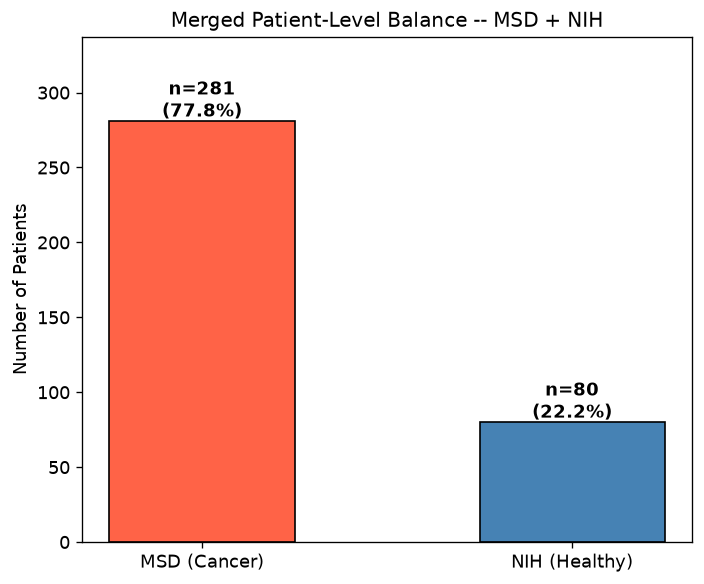

✅ Saved: eda_merged_class_balance.png


In [20]:
n_msd = len(df_patients)          # from Section D1 -- all 281 are cancer
n_nih = len(df_nih_props)          # from Section L3 -- all healthy
n_total = n_msd + n_nih

print("=" * 55)
print("  MERGED PATIENT-LEVEL CLASS BALANCE")
print("=" * 55)
print(f"  MSD (cancer):   {n_msd:4d}  ({100*n_msd/n_total:.1f}%)")
print(f"  NIH (healthy):  {n_nih:4d}  ({100*n_nih/n_total:.1f}%)")
print(f"  Total:          {n_total:4d}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['MSD (Cancer)', 'NIH (Healthy)'], [n_msd, n_nih],
       color=['tomato', 'steelblue'], edgecolor='black', width=0.5)
for i, v in enumerate([n_msd, n_nih]):
    ax.text(i, v + 3, f"n={v}\n({100*v/n_total:.1f}%)", ha='center', fontweight='bold')
ax.set_title('Merged Patient-Level Balance -- MSD + NIH')
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, max(n_msd, n_nih) * 1.2)
plt.tight_layout()
plt.savefig('eda_merged_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\u2705 Saved: eda_merged_class_balance.png")

### L5. Merged Slice-Level Balance

Combines MSD's slice-level counts (Section D1) with NIH. NIH's tumour-slice count is confidently **0** — that's true by definition for a healthy cohort regardless of mask availability, no segmentation needed to know a healthy patient has no tumour. What genuinely can't be determined without a pancreas mask is how NIH's slices split between "pancreas visible" and "background only" — reported as its own honest category rather than guessed into one bucket or the other.

In [21]:
nih_total_slices = int(df_nih_props.n_slices.sum())

merged_total_slices = total_slices + nih_total_slices
merged_tumour_slices = tumour_slices + 0  # NIH: axiomatically 0, healthy cohort

print("=" * 55)
print("  MERGED SLICE-LEVEL BALANCE")
print("=" * 55)
print(f"  MSD total slices:              {total_slices:,}")
print(f"    - tumour:                    {tumour_slices:,} ({100*tumour_slices/total_slices:.1f}%)")
print(f"    - pancreas-only:             {pancreas_slices:,} ({100*pancreas_slices/total_slices:.1f}%)")
print(f"    - background-only:           {bg_slices:,} ({100*bg_slices/total_slices:.1f}%)")
print(f"\n  NIH total slices:               {nih_total_slices:,}")
print(f"    - tumour:                    0 (0.0%) -- healthy cohort, by definition")
print(f"    - pancreas-only / background: UNDETERMINED -- no usable pancreas mask this pass")

print(f"\n  {'-'*53}")
print(f"  MERGED total slices:            {merged_total_slices:,}")
print(f"  MERGED tumour slices:           {merged_tumour_slices:,} "
      f"({100*merged_tumour_slices/merged_total_slices:.1f}% of all slices)")
print(f"  \u26a0 Merged pancreas-only/background split NOT reported -- would "
      f"require assuming a value for {nih_total_slices:,} unlabeled NIH slices."
)

  MERGED SLICE-LEVEL BALANCE
  MSD total slices:              26,719
    - tumour:                    2,537 (9.5%)
    - pancreas-only:             6,255 (23.4%)
    - background-only:           17,927 (67.1%)

  NIH total slices:               18,942
    - tumour:                    0 (0.0%) -- healthy cohort, by definition
    - pancreas-only / background: UNDETERMINED -- no usable pancreas mask this pass

  -----------------------------------------------------
  MERGED total slices:            45,661
  MERGED tumour slices:           2,537 (5.6% of all slices)
  ⚠ Merged pancreas-only/background split NOT reported -- would require assuming a value for 18,942 unlabeled NIH slices.


### L6. NIH Image Properties & HU Window Check

Confirms whether the [-150, +250] HU window chosen from MSD (Section G) still makes sense for NIH scans, and whether NIH's spacing needs different handling than the 1mm-isotropic resample already planned for MSD (Section K's preprocessing plan).

In [22]:
print("=" * 55)
print("  NIH IMAGE PROPERTIES")
print("=" * 55)
print(f"  Resolution: {df_nih_props.height.min()}-{df_nih_props.height.max()} x "
      f"{df_nih_props.width.min()}-{df_nih_props.width.max()} px")
print(f"  Slices per volume: {df_nih_props.n_slices.min()}-{df_nih_props.n_slices.max()}")
print(f"  Spacing X: {df_nih_props.spacing_x.min():.3f}-{df_nih_props.spacing_x.max():.3f} mm")
print(f"  Spacing Y: {df_nih_props.spacing_y.min():.3f}-{df_nih_props.spacing_y.max():.3f} mm")
print(f"  Spacing Z: {df_nih_props.spacing_z.min():.3f}-{df_nih_props.spacing_z.max():.3f} mm "
      f"(this copy is pre-resampled -- raw TCIA's actual slice thickness is 1.5-2.5mm, see Section L intro)")

random.seed(11)
nih_sample_files = random.sample(nih_img_files, 20)
nih_hu_values = []
nih_failed_hu = []
for fname in nih_sample_files:
    try:
        ct, _ = load_ct(fname, NIH_IMG_DIR)
    except CTLoadError as e:
        nih_failed_hu.append(e.fname)
        continue
    nih_hu_values.extend(ct.flatten()[::50].tolist())

nih_hu_values = np.array(nih_hu_values)
nih_p_low, nih_p_high = np.percentile(nih_hu_values, [0.5, 99.5])

print(f"\n{'-'*55}")
print(f"  NIH HU DISTRIBUTION (20-patient sample, global -- no pancreas mask "
      f"to isolate organ-specific HU this pass)")
print(f"{'-'*55}")
print(f"  0.5th percentile HU:   {nih_p_low:.1f}")
print(f"  99.5th percentile HU:  {nih_p_high:.1f}")
print(f"  MSD-derived window:    [-150, +250]")
if nih_failed_hu:
    print(f"  \u26a0 {len(nih_failed_hu)} patients failed to load and were skipped: {nih_failed_hu}")

nih_window_ok = abs(nih_p_low - (-150)) <= 50 and abs(nih_p_high - 250) <= 50
if nih_window_ok:
    print(f"\n  \u2705 CONFIRMED: [-150, +250] is consistent with NIH's empirical percentile range.")
else:
    print(f"\n  \u26a0 FLAG: NIH's empirical percentiles differ from the window by >50 HU on at "
          f"least one side (same whole-image-percentile caveat as MSD's own Section G2 check -- "
          f"background air dominates the low end, so this doesn't necessarily mean the "
          f"clinically-derived window is wrong for NIH tissue, but the raw numbers don't confirm "
          f"it either).")

  NIH IMAGE PROPERTIES
  Resolution: 512-512 x 512-512 px
  Slices per volume: 181-466
  Spacing X: 0.664-0.977 mm
  Spacing Y: 0.664-0.977 mm
  Spacing Z: 0.500-1.000 mm (this copy is pre-resampled -- raw TCIA's actual slice thickness is 1.5-2.5mm, see Section L intro)



-------------------------------------------------------
  NIH HU DISTRIBUTION (20-patient sample, global -- no pancreas mask to isolate organ-specific HU this pass)
-------------------------------------------------------
  0.5th percentile HU:   -2048.0
  99.5th percentile HU:  384.0
  MSD-derived window:    [-150, +250]

  ⚠ FLAG: NIH's empirical percentiles differ from the window by >50 HU on at least one side (same whole-image-percentile caveat as MSD's own Section G2 check -- background air dominates the low end, so this doesn't necessarily mean the clinically-derived window is wrong for NIH tissue, but the raw numbers don't confirm it either).


### L7. Lesion Size — Not Applicable

NIH patients are healthy — there is no lesion to measure, by definition, independent of any mask availability question. NIH patients are therefore excluded from the lesion-size-based stratification used for MSD's train/val/test split (preprocessing pipeline, `docs/CT_Preprocessing_documentation.md`) — they'd need their own stratification key (e.g. plain patient-level random split) when incorporated into that pipeline.

### L8. Risk-Score Validation — Deferred, Not Fabricated

The existing risk-score formula (`tumour_px / (pancreas_px + tumour_px)`, floored at denom<50 — preprocessing pipeline, Section 7) requires a tumour mask and a pancreas mask to compute per slice. Neither exists for NIH in this data copy (Section L intro) — so this cannot be empirically validated against real mask arrays right now, and pretending otherwise would be reporting a result that wasn't actually computed.

**By construction**, the correct value for every NIH slice is 0 -- there is no tumour label possible for a healthy patient regardless of whether a mask array exists to prove it numerically. This is a logical deferral: revisit once a genuine single-organ pancreas mask is available for NIH (e.g. from the original raw TCIA/NBIA download), and confirm `compute_slice_risk_score(mask_slice, floor) == 0.0` for every one of NIH's slices at that point -- not before.